# Orion 6 — u_target Threshold Fitting

Fit per-cluster linear models for the adaptive allocator on the
Samsung Orion 6 platform (3 clusters: 2 big + 1 small).

**Approach**: Each non-maximal cluster is treated as a standalone
homogeneous 4-core platform. We sweep the static `u_target` threshold
on each solo platform independently, find the optimal threshold per
scenario, then fit `u_target* = A·u_max + B·U_total + C`.

In [1]:
import os
import sys
import random
from pathlib import Path

sys.path.insert(0, str(Path("build/python").resolve()))

import pyschedsim as sim
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from drs import drs
from IPython.display import clear_output

try:
    get_ipython().run_line_magic("load_ext", "autoreload")
    get_ipython().run_line_magic("autoreload", "2")
except Exception:
    pass

In [2]:
PLATFORM_SMALL = "platforms/orion6_small.json"
PLATFORM_MEDIUM = "platforms/orion6_medium.json"
PLATFORM_FULL = "platforms/orion6.json"

N_SCENARIOS = 100
SUCCESS_RATE = 1.0  # Valid rates are in (0, 1]; 1.0 keeps all jobs within WCET.
COMPRESSION_RATE = 1.0
NUM_HYPERPERIODS = 100
MIN_JOBS = 200
UTIL_PER_TASK_MIN = 0.001

## Platform overview

The full Orion 6 has 3 clusters. We extract each non-maximal cluster
as its own solo platform (4 homogeneous cores, capacity = 4.0).

| Solo platform | effective_freq | freq range | Origin |
|---------------|---------------|------------|--------|
| `orion6_small.json`  | 800  | [800, 1800]        | Cluster 2 (perf=0.444) |
| `orion6_medium.json` | 1200 | [800..2400] (7 levels) | Cluster 1 (perf=1.0) |

In [3]:
for label, path in [("Small", PLATFORM_SMALL), ("Medium", PLATFORM_MEDIUM)]:
    engine = sim.Engine()
    sim.load_platform(engine, path)
    p = engine.platform
    cd = p.clock_domain(0)
    procs = cd.get_processors()
    print(
        f"{label}: freq_eff={cd.freq_eff}, freq_max={cd.freq_max}, "
        f"procs={len(procs)}, perf={procs[0].type().performance}"
    )
    del engine

Small: freq_eff=800.0, freq_max=1800.0, procs=4, perf=1.0
Medium: freq_eff=1200.0, freq_max=2400.0, procs=4, perf=1.0


## Taskset Generation

Unbounded DRS with per-task utilization in [0.001, 1.0].
Total utilization in [0.1, 4.0] — the full range of a 4-core platform.
These tasksets are shared by both sweeps.

In [4]:
TASKSET_DIR = "tasksets_orion6_solo"
UTIL_UNBOUNDED_LO = UTIL_PER_TASK_MIN
UTIL_UNBOUNDED_HI = 1.0
UTIL_UNBOUNDED_MID = (UTIL_UNBOUNDED_LO + UTIL_UNBOUNDED_HI) / 2

UTIL_MIN = 5.0
UTIL_MAX = 8.5
UTIL_STEP = 0.3
util_points = np.round(np.arange(UTIL_MIN, UTIL_MAX + UTIL_STEP / 2, UTIL_STEP), 4)
print(f"Utilization points: {len(util_points)} from {util_points[0]} to {util_points[-1]}")

Utilization points: 13 from 5.0 to 8.6


In [5]:
tasksets = []
for j, util in enumerate(util_points):
    n_tasks_u = max(
        int(np.ceil(util / UTIL_UNBOUNDED_HI)),
        round(util / UTIL_UNBOUNDED_MID),
    )
    folder = os.path.join(TASKSET_DIR, str(int(round(util * 10))))
    os.makedirs(folder, exist_ok=True)
    for scenario_idx in range(N_SCENARIOS):
        seed = int(round(util * 10000)) * 40000 + scenario_idx
        random.seed(seed)
        utils = drs(
            n_tasks_u,
            util,
            upper_bounds=[UTIL_UNBOUNDED_HI] * n_tasks_u,
            lower_bounds=[UTIL_UNBOUNDED_LO] * n_tasks_u,
        )
        scenario = sim.from_utilizations(
            utils, SUCCESS_RATE, COMPRESSION_RATE, seed, NUM_HYPERPERIODS, MIN_JOBS
        )
        path = os.path.join(folder, f"{scenario_idx + 1}.json")
        sim.write_scenario(scenario, path)
        tasksets.append({
            "total_util": round(float(util), 4),
            "seed": seed,
            "utilizations": [float(u) for u in utils],
            "u_max": float(max(utils)),
            "path": path,
        })
    clear_output(wait=True)
    print(f"  U={util:.1f} -> {folder}/  ({j + 1}/{len(util_points)})")

print(f"\nGenerated {len(tasksets)} tasksets in {TASKSET_DIR}/")

  U=8.6 -> tasksets_orion6_solo/86/  (13/13)

Generated 1300 tasksets in tasksets_orion6_solo/


### Utilization distribution

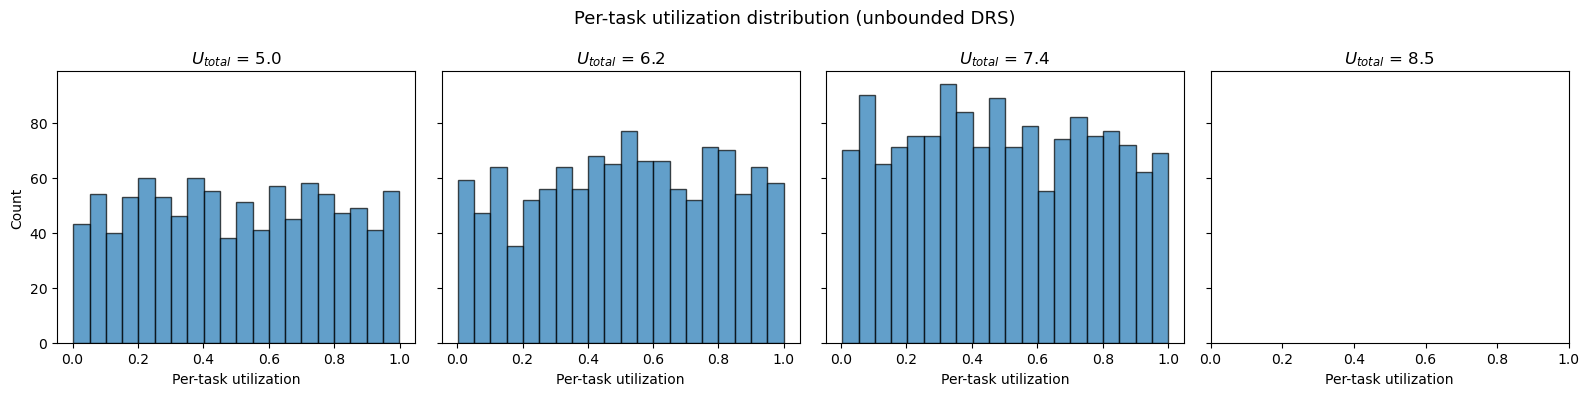

In [6]:
sample_points = [5.0, 6.2, 7.4, 8.5]
fig, axes = plt.subplots(1, len(sample_points), figsize=(16, 4), sharey=True)

for ax, target in zip(axes, sample_points):
    target_r = round(target, 4)
    all_utils = [
        u for t in tasksets if t["total_util"] == target_r for u in t["utilizations"]
    ]
    if all_utils:
        ax.hist(all_utils, bins=20, edgecolor="black", alpha=0.7)
    ax.set_title(f"$U_{{total}}$ = {target:.1f}")
    ax.set_xlabel("Per-task utilization")

axes[0].set_ylabel("Count")
fig.suptitle("Per-task utilization distribution (unbounded DRS)", fontsize=13)
plt.tight_layout()
plt.show()

## Grid search on full Orion 6 platform

2D sweep of `(u_target_small, u_target_medium)` on the full 3-cluster
platform. Big cluster stays at `u_target=1.0`.

In [7]:
PLATFORM_FULL = "platforms/orion6.json"

U_TARGET_GRID = np.round(np.arange(0.4, 1.0 + 0.02, 0.02), 4)
print(
    f"Grid: {len(U_TARGET_GRID)}x{len(U_TARGET_GRID)} = "
    f"{len(U_TARGET_GRID)**2} combos per taskset"
)
print(
    f"Total simulations: {len(U_TARGET_GRID)**2} x {len(tasksets)} = "
    f"{len(U_TARGET_GRID)**2 * len(tasksets)}"
)

Grid: 31x31 = 961 combos per taskset
Total simulations: 961 x 1300 = 1249300


In [8]:
from multiprocessing import Pool
import os

from _grid_worker import run_grid

combos = [(s, m) for s in U_TARGET_GRID for m in U_TARGET_GRID]
work_items = [
    (t, float(ut_s), float(ut_m))
    for ut_s, ut_m in combos
    for t in tasksets
]

n_workers = os.cpu_count() or 4
print(f"Running {len(work_items)} simulations on {n_workers} cores...")

with Pool(n_workers) as pool:
    grid_rows = pool.map(run_grid, work_items, chunksize=64)

df_grid = pl.DataFrame(grid_rows)
print(f"Done: {len(df_grid)} rows")

Running 1249300 simulations on 14 cores...


Done: 1249300 rows


### Best (u_target_small, u_target_medium) per utilization level

In [9]:
grid_summary = (
    df_grid.group_by(["u_target_small", "u_target_medium", "total_util"])
    .agg(
        acceptance_rate=1.0
        - pl.col("rejected_arrivals").sum() / pl.col("total_arrivals").sum(),
    )
    .sort(["total_util", "acceptance_rate"], descending=[False, True])
)

best_grid = (
    grid_summary.group_by("total_util", maintain_order=True)
    .first()
    .sort("total_util")
)

print("Best (u_target_small, u_target_medium) per utilization level:\n")
for row in best_grid.iter_rows(named=True):
    print(
        f"  U={row['total_util']:.1f}: "
        f"small={row['u_target_small']:.2f}, medium={row['u_target_medium']:.2f} "
        f"-> acceptance={row['acceptance_rate']:.4f}"
    )

Best (u_target_small, u_target_medium) per utilization level:

  U=5.0: small=0.88, medium=0.88 -> acceptance=0.7583
  U=5.3: small=0.68, medium=0.82 -> acceptance=0.7438
  U=5.6: small=0.98, medium=0.76 -> acceptance=0.7180
  U=5.9: small=0.92, medium=0.80 -> acceptance=0.7255
  U=6.2: small=0.96, medium=0.76 -> acceptance=0.6986
  U=6.5: small=0.88, medium=0.76 -> acceptance=0.6857
  U=6.8: small=0.96, medium=0.74 -> acceptance=0.6826
  U=7.1: small=0.82, medium=0.72 -> acceptance=0.6802
  U=7.4: small=0.80, medium=0.76 -> acceptance=0.6729
  U=7.7: small=0.82, medium=0.76 -> acceptance=0.6530
  U=8.0: small=0.88, medium=0.68 -> acceptance=0.6334
  U=8.3: small=0.90, medium=0.66 -> acceptance=0.6442
  U=8.6: small=0.90, medium=0.64 -> acceptance=0.6138


---
## Linear model fitting from grid search

Extract per-scenario optimal `(u_target_small, u_target_medium)` from
the grid search, then fit two independent linear models:
- $u^*_{small} = A_1 \cdot u_{max} + B_1 \cdot U_{total} + C_1$
- $u^*_{medium} = A_2 \cdot u_{max} + B_2 \cdot U_{total} + C_2$

In [10]:
# Per-scenario acceptance rate
per_scenario_grid = df_grid.with_columns(
    (
        (pl.col("total_arrivals") - pl.col("rejected_arrivals"))
        / pl.col("total_arrivals")
    ).alias("acceptance_rate")
)

# For each scenario, find the (u_target_small, u_target_medium) pair
# that maximizes acceptance rate. Break ties by highest thresholds.
optimal_pairs = (
    per_scenario_grid.sort(
        ["total_util", "seed", "acceptance_rate", "u_target_small", "u_target_medium"],
        descending=[False, False, True, True, True],
    )
    .group_by(["total_util", "seed"], maintain_order=True)
    .first()
    .select([
        "total_util", "seed", "u_max",
        "u_target_small", "u_target_medium", "acceptance_rate",
    ])
    .sort(["total_util", "seed"])
)

print(f"Per-scenario optimal pairs: {len(optimal_pairs)}")
optimal_pairs.head(10)

Per-scenario optimal pairs: 1300


total_util,seed,u_max,u_target_small,u_target_medium,acceptance_rate
f64,i64,f64,f64,f64,f64
5.0,2000000000,0.96832,1.0,0.76,0.764706
5.0,2000000001,0.983185,1.0,1.0,0.733333
5.0,2000000002,0.971125,1.0,1.0,0.826087
5.0,2000000003,0.976942,1.0,1.0,0.714286
5.0,2000000004,0.996732,1.0,1.0,0.916667
5.0,2000000005,0.972894,1.0,1.0,0.8
5.0,2000000006,0.982817,1.0,1.0,0.647059
5.0,2000000007,0.927231,1.0,1.0,0.7
5.0,2000000008,0.991951,1.0,1.0,0.866667


### Linear fit — small cluster

In [11]:
X = np.column_stack([
    optimal_pairs["u_max"].to_numpy(),
    optimal_pairs["total_util"].to_numpy(),
    np.ones(len(optimal_pairs)),
])

y_small = optimal_pairs["u_target_small"].to_numpy()
coeffs_small, _, _, _ = np.linalg.lstsq(X, y_small, rcond=None)
A_small, B_small, C_small = coeffs_small

y_pred_small = X @ coeffs_small
ss_res = np.sum((y_small - y_pred_small) ** 2)
ss_tot = np.sum((y_small - np.mean(y_small)) ** 2)
r2_small = 1 - ss_res / ss_tot if ss_tot > 0 else 0
mae_small = np.mean(np.abs(y_small - y_pred_small))

print("Small cluster linear model:")
print(f"  u_target = {A_small:.6f} * u_max + {B_small:.6f} * U_total + {C_small:.6f}")
print(f"  R² = {r2_small:.4f}, MAE = {mae_small:.6f}")

Small cluster linear model:
  u_target = -0.049762 * u_max + 0.000869 * U_total + 1.029915
  R² = 0.0022, MAE = 0.020374


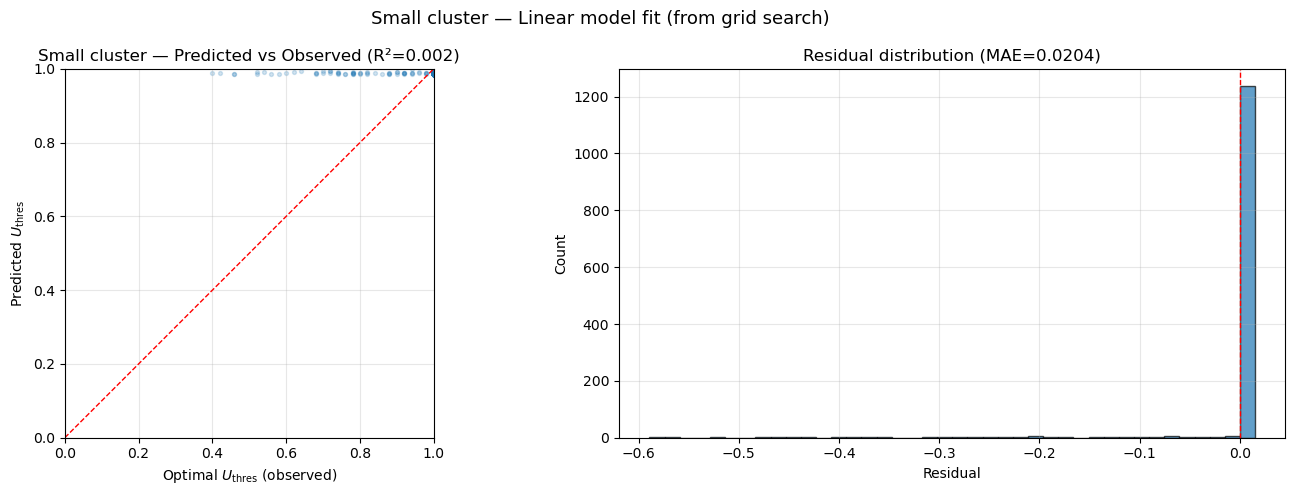

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_small, y_pred_small, alpha=0.2, s=8)
axes[0].plot([0, 1], [0, 1], "r--", linewidth=1)
axes[0].set_xlabel("Optimal $U_{\\mathrm{thres}}$ (observed)")
axes[0].set_ylabel("Predicted $U_{\\mathrm{thres}}$")
axes[0].set_title(f"Small cluster — Predicted vs Observed (R²={r2_small:.3f})")
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1])
axes[0].set_aspect("equal")
axes[0].grid(True, alpha=0.3)

residuals_small = y_small - y_pred_small
axes[1].hist(residuals_small, bins=40, edgecolor="black", alpha=0.7)
axes[1].axvline(0, color="red", linewidth=1, linestyle="--")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")
axes[1].set_title(f"Residual distribution (MAE={mae_small:.4f})")
axes[1].grid(True, alpha=0.3)

fig.suptitle("Small cluster — Linear model fit (from grid search)", fontsize=13)
plt.tight_layout()
plt.show()

### Linear fit — medium cluster

In [13]:
y_medium = optimal_pairs["u_target_medium"].to_numpy()
coeffs_medium, _, _, _ = np.linalg.lstsq(X, y_medium, rcond=None)
A_medium, B_medium, C_medium = coeffs_medium

y_pred_medium = X @ coeffs_medium
ss_res_m = np.sum((y_medium - y_pred_medium) ** 2)
ss_tot_m = np.sum((y_medium - np.mean(y_medium)) ** 2)
r2_medium = 1 - ss_res_m / ss_tot_m if ss_tot_m > 0 else 0
mae_medium = np.mean(np.abs(y_medium - y_pred_medium))

print("Medium cluster linear model:")
print(f"  u_target = {A_medium:.6f} * u_max + {B_medium:.6f} * U_total + {C_medium:.6f}")
print(f"  R² = {r2_medium:.4f}, MAE = {mae_medium:.6f}")

Medium cluster linear model:
  u_target = 0.278822 * u_max + -0.041360 * U_total + 0.897100
  R² = 0.1216, MAE = 0.105360


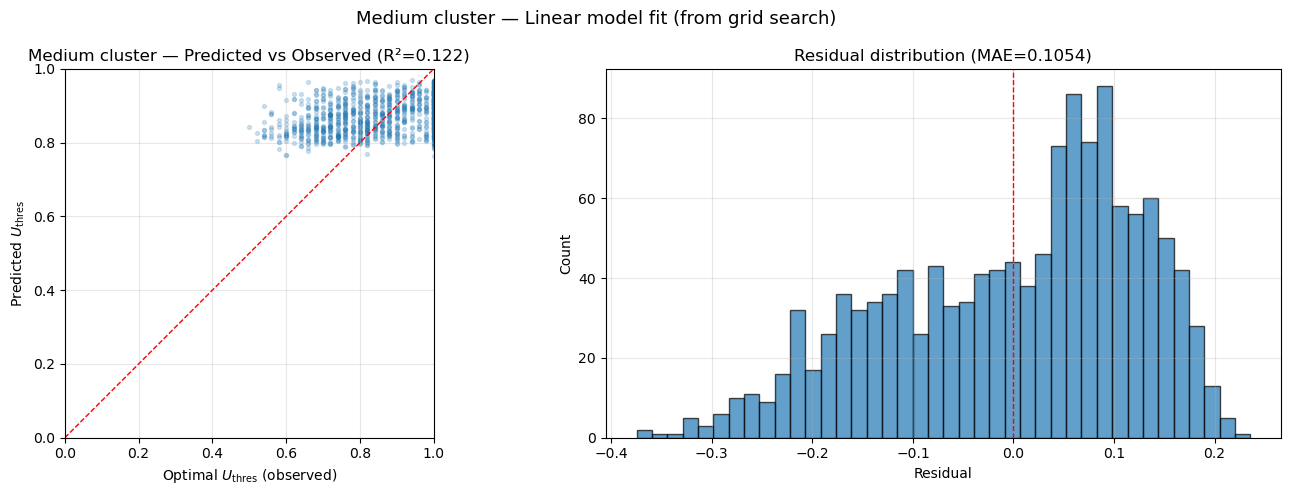

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_medium, y_pred_medium, alpha=0.2, s=8)
axes[0].plot([0, 1], [0, 1], "r--", linewidth=1)
axes[0].set_xlabel("Optimal $U_{\\mathrm{thres}}$ (observed)")
axes[0].set_ylabel("Predicted $U_{\\mathrm{thres}}$")
axes[0].set_title(f"Medium cluster — Predicted vs Observed (R²={r2_medium:.3f})")
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1])
axes[0].set_aspect("equal")
axes[0].grid(True, alpha=0.3)

residuals_medium = y_medium - y_pred_medium
axes[1].hist(residuals_medium, bins=40, edgecolor="black", alpha=0.7)
axes[1].axvline(0, color="red", linewidth=1, linestyle="--")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Count")
axes[1].set_title(f"Residual distribution (MAE={mae_medium:.4f})")
axes[1].grid(True, alpha=0.3)

fig.suptitle("Medium cluster — Linear model fit (from grid search)", fontsize=13)
plt.tight_layout()
plt.show()

---
## Summary

In [15]:
print("=" * 65)
print("Orion 6 — Fitted Linear Models (from grid search)")
print("=" * 65)
print()
print("Small cluster (perf=0.444, scale_factor~3.25):")
print(f"  u_target = {A_small:.6f} * u_max + {B_small:.6f} * U_total + {C_small:.6f}")
print(f"  R² = {r2_small:.4f}, MAE = {mae_small:.6f}")
print()
print("Medium cluster (perf=1.0, freq_max=2400, scale_factor~1.08):")
print(f"  u_target = {A_medium:.6f} * u_max + {B_medium:.6f} * U_total + {C_medium:.6f}")
print(f"  R² = {r2_medium:.4f}, MAE = {mae_medium:.6f}")
print()
print("C++ constants:")
print()
print("// Small cluster (Orion 6)")
print(f"constexpr double A_UMAX_SMALL = {A_small:.6f};")
print(f"constexpr double B_U_SMALL    = {B_small:.6f};")
print(f"constexpr double C_SMALL      = {C_small:.6f};")
print()
print("// Medium cluster (Orion 6)")
print(f"constexpr double A_UMAX_MEDIUM = {A_medium:.6f};")
print(f"constexpr double B_U_MEDIUM    = {B_medium:.6f};")
print(f"constexpr double C_MEDIUM      = {C_medium:.6f};")

Orion 6 — Fitted Linear Models (from grid search)

Small cluster (perf=0.444, scale_factor~3.25):
  u_target = -0.049762 * u_max + 0.000869 * U_total + 1.029915
  R² = 0.0022, MAE = 0.020374

Medium cluster (perf=1.0, freq_max=2400, scale_factor~1.08):
  u_target = 0.278822 * u_max + -0.041360 * U_total + 0.897100
  R² = 0.1216, MAE = 0.105360

C++ constants:

// Small cluster (Orion 6)
constexpr double A_UMAX_SMALL = -0.049762;
constexpr double B_U_SMALL    = 0.000869;
constexpr double C_SMALL      = 1.029915;

// Medium cluster (Orion 6)
constexpr double A_UMAX_MEDIUM = 0.278822;
constexpr double B_U_MEDIUM    = -0.041360;
constexpr double C_MEDIUM      = 0.897100;
